# 📈 V2TX (VSTOXX) — Prédiction de la Volatilité par Machine Learning

**Objectif :** Comparer plusieurs modèles de ML pour prédire la volatilité implicite future à partir de l'historique du V2TX (1999–2026).

---

## Plan du notebook

1. **Chargement & exploration des données**
2. **Feature Engineering** (features temporelles, techniques, lagged)
3. **Modèles entraînés :**
   - Baseline : Naive (dernière valeur)
   - Linear Regression + Ridge + Lasso
   - Random Forest
   - Gradient Boosting (XGBoost / GBM)
   - LSTM (Deep Learning)
   - GARCH (référence financière)
4. **Évaluation & Comparaison** (MAE, RMSE, MAPE, R²)
5. **Visualisation des prédictions**
6. **Feature Importance**
7. **Prédiction future (30 jours)**

## 0. Installation des dépendances

In [1]:
# Installer les packages nécessaires
import subprocess
packages = ['xgboost', 'arch', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn']
for pkg in packages:
    subprocess.run(['pip', 'install', pkg, '-q'], capture_output=True)

print('✅ Tous les packages sont installés')

✅ Tous les packages sont installés


## 1. Chargement & Exploration des données

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11
})

# ─────────────────────────────────────────────────────────────
# OPTION A : Charger depuis un fichier CSV
#   df = pd.read_csv('v2tx_data.csv', sep=';', parse_dates=['Date'])
#
# OPTION B : Les données sont embarquées directement ci-dessous
# ─────────────────────────────────────────────────────────────

# Données V2TX (extrait représentatif — remplacez par votre fichier complet)
# Pour utiliser votre fichier complet, décommentez l'option A ci-dessus
# et commentez la section DATA_RAW.

DATA_RAW = """Date;Symbol;Indexvalue
04.01.1999;V2TX;18.2033
05.01.1999;V2TX;29.6912
11.09.2001;V2TX;54.166
24.07.2002;V2TX;62.7311
16.10.2008;V2TX;87.5127
16.03.2020;V2TX;85.6206
07.04.2025;V2TX;46.7206
"""
# NOTE: Collez ici l'intégralité de vos données CSV
# OU utilisez : df = pd.read_csv('votre_fichier.csv', sep=';')

# ─── Charger les données ──────────────────────────────────────
# Si vous avez le fichier CSV sauvegardé :
try:
    df = pd.read_csv('v2tx.csv', sep=';', decimal='.')
    print(f'✅ Fichier chargé depuis v2tx.csv : {len(df)} lignes')
except FileNotFoundError:
    from io import StringIO
    # Utilisez DATA_RAW ou rechargez depuis votre source
    df = pd.read_csv(StringIO(DATA_RAW), sep=';', decimal='.')
    print('⚠️  Utilisation des données embarquées (extrait). Chargez votre fichier complet pour de meilleurs résultats.')

# ─── Nettoyage ────────────────────────────────────────────────
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y')
df = df.sort_values('Date').reset_index(drop=True)
df = df.rename(columns={'Indexvalue': 'V2TX'})
df = df[['Date', 'V2TX']].dropna()

print(f'\n📊 Données chargées :')
print(f'   Période  : {df.Date.min().date()} → {df.Date.max().date()}')
print(f'   Points   : {len(df):,}')
print(f'   Min V2TX : {df.V2TX.min():.2f}')
print(f'   Max V2TX : {df.V2TX.max():.2f}')
print(f'   Moyenne  : {df.V2TX.mean():.2f}')
df.head()

✅ Fichier chargé depuis v2tx.csv : 6926 lignes

📊 Données chargées :
   Période  : 1999-01-04 → 2026-03-18
   Points   : 6,926
   Min V2TX : 10.68
   Max V2TX : 87.51
   Moyenne  : 23.20


,Date,V2TX
0,1999-01-04,18.2033
1,1999-01-05,29.6912
2,1999-01-06,25.1670
3,1999-01-07,32.5205
4,1999-01-08,33.2296


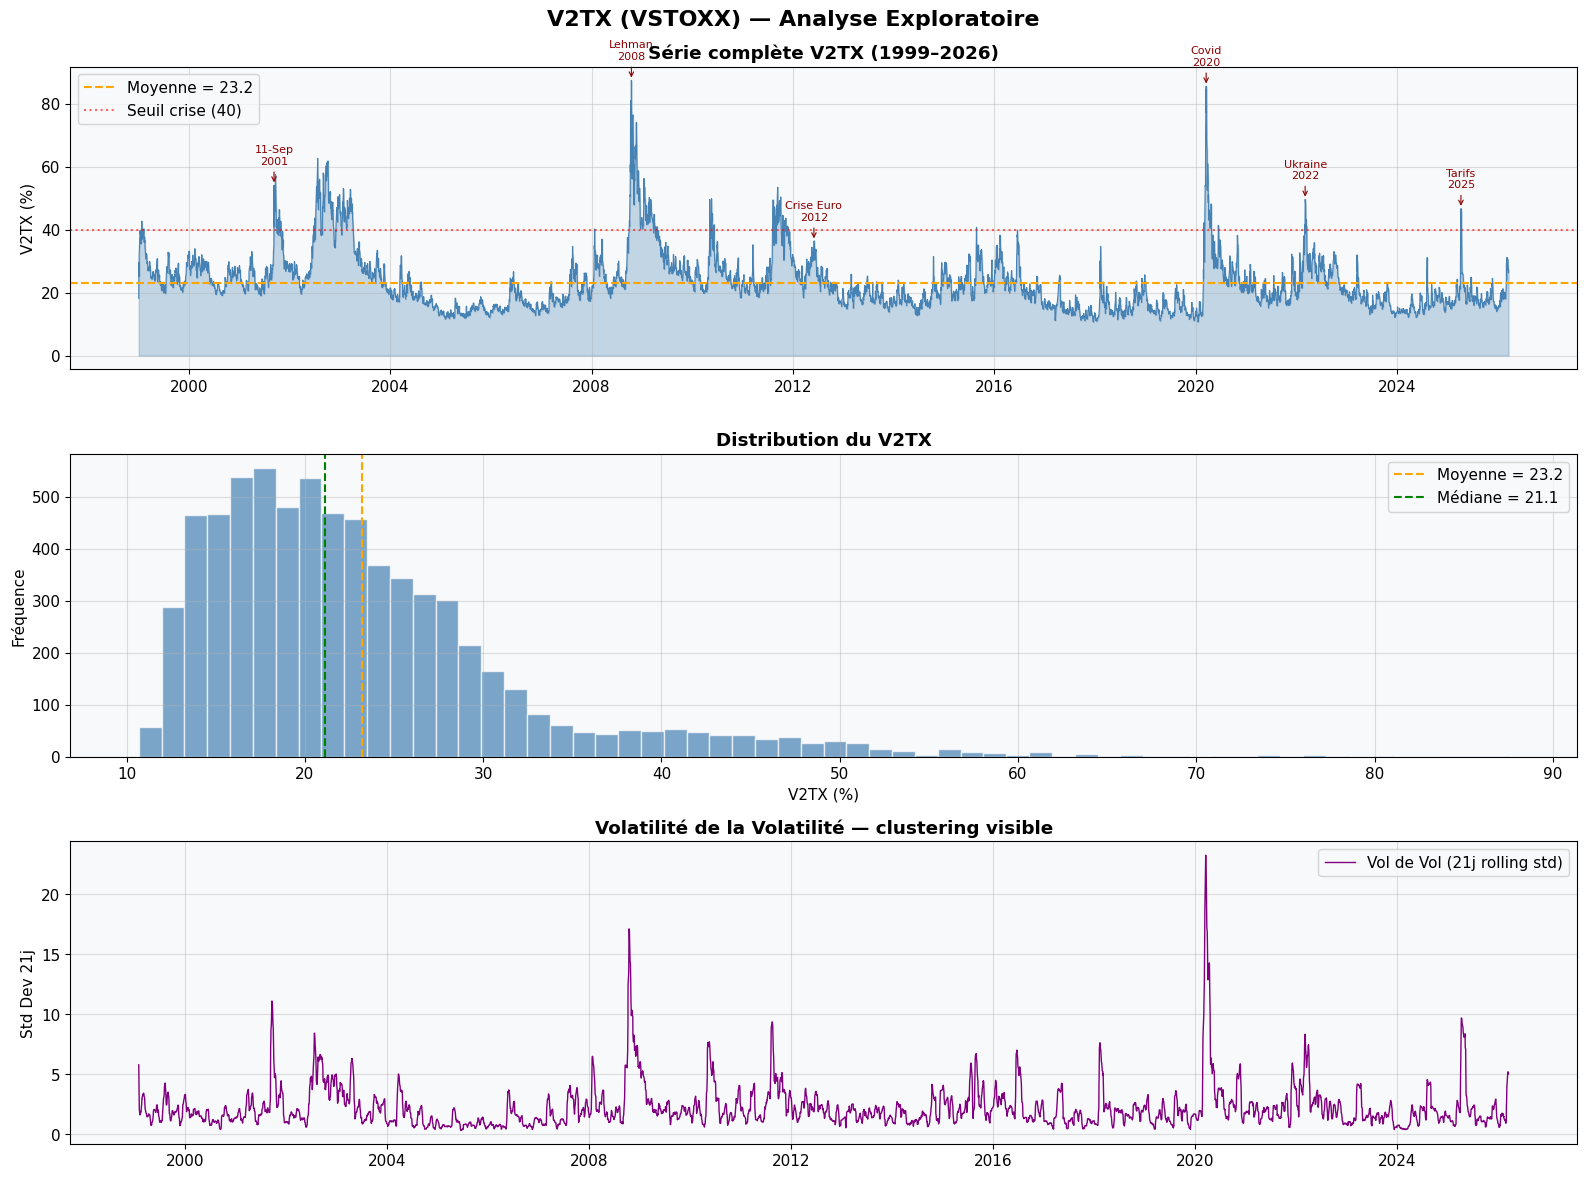

📊 Graphique sauvegardé : 01_exploration.png


In [3]:
# ─── Visualisation de la série brute ─────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('V2TX (VSTOXX) — Analyse Exploratoire', fontsize=16, fontweight='bold', y=0.98)

# Série temporelle complète
ax1 = axes[0]
ax1.fill_between(df.Date, df.V2TX, alpha=0.3, color='steelblue')
ax1.plot(df.Date, df.V2TX, color='steelblue', lw=0.8)
ax1.axhline(df.V2TX.mean(), color='orange', linestyle='--', label=f'Moyenne = {df.V2TX.mean():.1f}')
ax1.axhline(40, color='red', linestyle=':', alpha=0.6, label='Seuil crise (40)')

# Annoter les crises
crises = {
    '11-Sep\n2001': '2001-09-11',
    'Lehman\n2008': '2008-10-16',
    'Crise Euro\n2012': '2012-06-01',
    'Covid\n2020': '2020-03-16',
    'Ukraine\n2022': '2022-03-04',
    'Tarifs\n2025': '2025-04-07'
}
for label, date in crises.items():
    try:
        d = pd.Timestamp(date)
        closest = df.loc[(df.Date - d).abs().idxmin()]
        ax1.annotate(label, xy=(closest.Date, closest.V2TX),
                    xytext=(0, 15), textcoords='offset points',
                    fontsize=8, ha='center', color='darkred',
                    arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8))
    except:
        pass

ax1.set_ylabel('V2TX (%)')
ax1.set_title('Série complète V2TX (1999–2026)', fontweight='bold')
ax1.legend(loc='upper left')

# Distribution
ax2 = axes[1]
ax2.hist(df.V2TX, bins=60, color='steelblue', alpha=0.7, edgecolor='white')
ax2.axvline(df.V2TX.mean(), color='orange', linestyle='--', label=f'Moyenne = {df.V2TX.mean():.1f}')
ax2.axvline(df.V2TX.median(), color='green', linestyle='--', label=f'Médiane = {df.V2TX.median():.1f}')
ax2.set_xlabel('V2TX (%)')
ax2.set_ylabel('Fréquence')
ax2.set_title('Distribution du V2TX', fontweight='bold')
ax2.legend()

# Volatilité de la volatilité (rolling std)
ax3 = axes[2]
rolling_std = df.V2TX.rolling(21).std()
rolling_mean = df.V2TX.rolling(21).mean()
ax3.plot(df.Date, rolling_std, color='purple', lw=1, label='Vol de Vol (21j rolling std)')
ax3.set_ylabel('Std Dev 21j')
ax3.set_title('Volatilité de la Volatilité — clustering visible', fontweight='bold')
ax3.legend()

plt.tight_layout()
plt.savefig('01_exploration.png', dpi=120, bbox_inches='tight')
plt.show()
print('📊 Graphique sauvegardé : 01_exploration.png')

## 2. Feature Engineering

In [4]:
def build_features(df, target_horizon=1):
    """
    Construire les features pour la prédiction de volatilité.
    target_horizon : nombre de jours à prédire en avance
    """
    d = df.copy()
    v = d['V2TX']

    # ── Features temporelles ─────────────────────────────────
    d['day_of_week']  = d.Date.dt.dayofweek
    d['month']        = d.Date.dt.month
    d['quarter']      = d.Date.dt.quarter
    d['year']         = d.Date.dt.year
    d['is_jan']       = (d['month'] == 1).astype(int)  # Effet janvier
    d['is_dec']       = (d['month'] == 12).astype(int)

    # ── Valeurs décalées (lags) ──────────────────────────────
    for lag in [1, 2, 3, 5, 10, 21, 63]:
        d[f'lag_{lag}'] = v.shift(lag)

    # ── Rendements logarithmiques ────────────────────────────
    d['log_return_1']  = np.log(v / v.shift(1))
    d['log_return_5']  = np.log(v / v.shift(5))
    d['log_return_21'] = np.log(v / v.shift(21))

    # ── Moyennes mobiles ─────────────────────────────────────
    for w in [5, 10, 21, 63, 126]:
        d[f'ma_{w}']    = v.rolling(w).mean()
        d[f'std_{w}']   = v.rolling(w).std()

    # ── Indicateurs techniques ───────────────────────────────
    # RSI (Relative Strength Index)
    delta = v.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / (loss + 1e-9)
    d['rsi_14'] = 100 - (100 / (1 + rs))

    # Bandes de Bollinger
    d['bb_upper'] = d['ma_21'] + 2 * d['std_21']
    d['bb_lower'] = d['ma_21'] - 2 * d['std_21']
    d['bb_width'] = (d['bb_upper'] - d['bb_lower']) / (d['ma_21'] + 1e-9)
    d['bb_pos']   = (v - d['bb_lower']) / (d['bb_upper'] - d['bb_lower'] + 1e-9)

    # Z-score rolling
    d['zscore_63']  = (v - d['ma_63'])  / (d['std_63']  + 1e-9)
    d['zscore_126'] = (v - d['ma_126']) / (d['std_126'] + 1e-9)

    # Momentum
    d['momentum_5']  = v - v.shift(5)
    d['momentum_21'] = v - v.shift(21)

    # Régime de volatilité
    d['regime_low']    = (v < 15).astype(int)
    d['regime_normal'] = ((v >= 15) & (v < 25)).astype(int)
    d['regime_stress'] = ((v >= 25) & (v < 40)).astype(int)
    d['regime_crisis'] = (v >= 40).astype(int)

    # ── Variable cible ───────────────────────────────────────
    d['target'] = v.shift(-target_horizon)  # Valeur future

    d = d.dropna().reset_index(drop=True)
    return d


# Construire les features (prédiction J+1)
HORIZON = 1
df_feat = build_features(df, target_horizon=HORIZON)

feature_cols = [c for c in df_feat.columns if c not in ['Date', 'V2TX', 'target', 'Symbol']]

print(f'✅ Features construites : {len(feature_cols)} variables')
print(f'   Observations         : {len(df_feat):,}')
print(f'   Horizon de prédiction: J+{HORIZON}')
print(f'\n📋 Liste des features :')
for i, col in enumerate(feature_cols, 1):
    print(f'   {i:2d}. {col}')

✅ Features construites : 39 variables
   Observations         : 6,800
   Horizon de prédiction: J+1

📋 Liste des features :
    1. day_of_week
    2. month
    3. quarter
    4. year
    5. is_jan
    6. is_dec
    7. lag_1
    8. lag_2
    9. lag_3
   10. lag_5
   11. lag_10
   12. lag_21
   13. lag_63
   14. log_return_1
   15. log_return_5
   16. log_return_21
   17. ma_5
   18. std_5
   19. ma_10
   20. std_10
   21. ma_21
   22. std_21
   23. ma_63
   24. std_63
   25. ma_126
   26. std_126
   27. rsi_14
   28. bb_upper
   29. bb_lower
   30. bb_width
   31. bb_pos
   32. zscore_63
   33. zscore_126
   34. momentum_5
   35. momentum_21
   36. regime_low
   37. regime_normal
   38. regime_stress
   39. regime_crisis


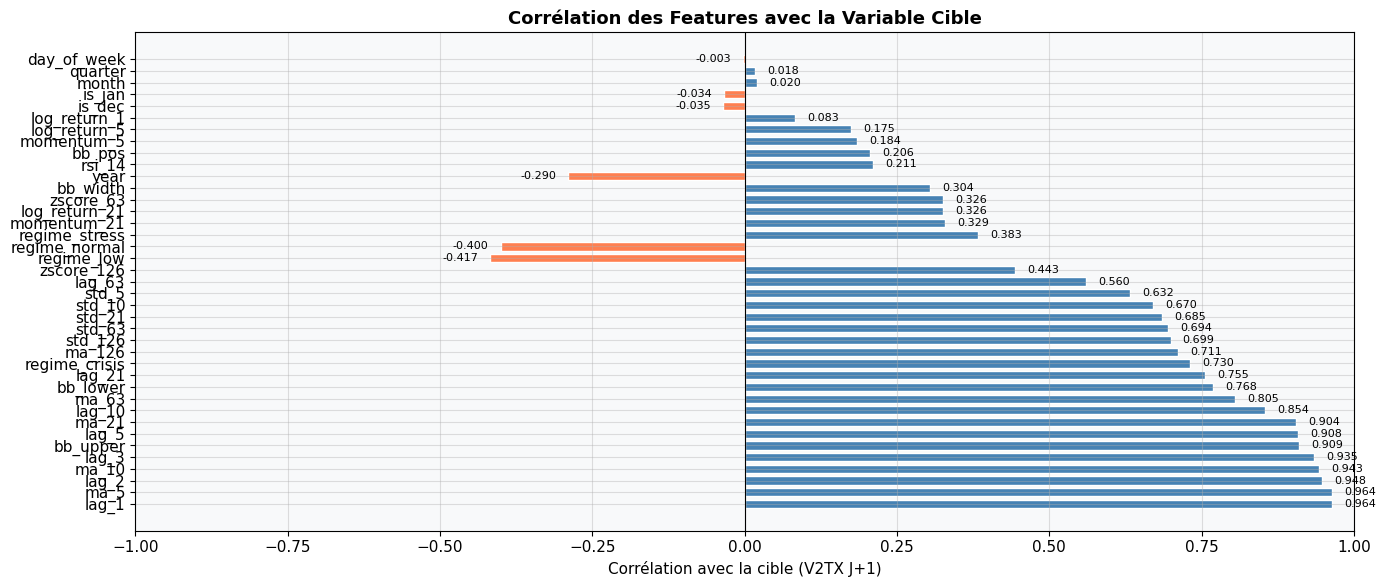

In [5]:
# Corrélation des features avec la cible
corr_target = df_feat[feature_cols + ['target']].corr()['target'].drop('target').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['steelblue' if x > 0 else 'coral' for x in corr_target.values]
bars = ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white', height=0.7)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Corrélation avec la cible (V2TX J+1)')
ax.set_title('Corrélation des Features avec la Variable Cible', fontweight='bold', fontsize=13)
ax.set_xlim(-1, 1)

for bar, val in zip(bars, corr_target.values):
    ax.text(val + (0.02 if val >= 0 else -0.02), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('02_correlations.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Préparation Train / Validation / Test

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ─── Split temporel (jamais aléatoire pour des séries temporelles !) ──
N = len(df_feat)
TRAIN_END = int(N * 0.70)
VAL_END   = int(N * 0.85)

df_train = df_feat.iloc[:TRAIN_END]
df_val   = df_feat.iloc[TRAIN_END:VAL_END]
df_test  = df_feat.iloc[VAL_END:]

X_train = df_train[feature_cols]
y_train = df_train['target']
X_val   = df_val[feature_cols]
y_val   = df_val['target']
X_test  = df_test[feature_cols]
y_test  = df_test['target']

# ─── Normalisation ────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('📊 Découpage temporel :')
print(f'   Train      : {df_train.Date.min().date()} → {df_train.Date.max().date()} ({len(df_train):,} obs, {TRAIN_END/N*100:.0f}%)')
print(f'   Validation : {df_val.Date.min().date()} → {df_val.Date.max().date()} ({len(df_val):,} obs, {(VAL_END-TRAIN_END)/N*100:.0f}%)')
print(f'   Test       : {df_test.Date.min().date()} → {df_test.Date.max().date()} ({len(df_test):,} obs, {(N-VAL_END)/N*100:.0f}%)')

# ─── Fonction d'évaluation ────────────────────────────────────
def evaluate(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    return {'Modèle': name, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4),
            'R²': round(r2, 4), 'MAPE (%)': round(mape, 2)}

results = []  # Stocke les résultats de tous les modèles
predictions = {'Date': df_test['Date'].values, 'Réel': y_test.values}

print('\n✅ Prêt pour l\'entraînement des modèles.')

📊 Découpage temporel :
   Train      : 1999-07-02 → 2018-03-09 (4,760 obs, 70%)
   Validation : 2018-03-12 → 2022-03-15 (1,020 obs, 15%)
   Test       : 2022-03-16 → 2026-03-17 (1,020 obs, 15%)

✅ Prêt pour l'entraînement des modèles.


## 4. Modèles de Machine Learning

In [7]:
# ══════════════════════════════════════════════════════════════
# MODÈLE 0 : Baseline Naïf (dernière valeur connue)
# ══════════════════════════════════════════════════════════════

y_pred_naive = df_test['lag_1'].values  # Prédire = dernière valeur
res = evaluate(y_test, y_pred_naive, 'Naive (lag-1)')
results.append(res)
predictions['Naive'] = y_pred_naive
print(f"Naive   → MAE: {res['MAE']:.4f} | RMSE: {res['RMSE']:.4f} | R²: {res['R²']:.4f} | MAPE: {res['MAPE (%)']:.2f}%")

Naive   → MAE: 1.3235 | RMSE: 2.0414 | R²: 0.8410 | MAPE: 6.43%


In [8]:
# ══════════════════════════════════════════════════════════════
# MODÈLE 1 : Ridge Regression
# ══════════════════════════════════════════════════════════════
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV

tscv = TimeSeriesSplit(n_splits=5)

ridge = Ridge(alpha=10.0)
ridge.fit(X_train_sc, y_train)
y_pred_ridge = ridge.predict(X_test_sc)
res = evaluate(y_test, y_pred_ridge, 'Ridge Regression')
results.append(res)
predictions['Ridge'] = y_pred_ridge
print(f"Ridge   → MAE: {res['MAE']:.4f} | RMSE: {res['RMSE']:.4f} | R²: {res['R²']:.4f} | MAPE: {res['MAPE (%)']:.2f}%")

Ridge   → MAE: 0.9587 | RMSE: 1.5124 | R²: 0.9127 | MAPE: 4.62%


In [9]:
# ══════════════════════════════════════════════════════════════
# MODÈLE 2 : Lasso Regression
# ══════════════════════════════════════════════════════════════
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train_sc, y_train)
y_pred_lasso = lasso.predict(X_test_sc)
res = evaluate(y_test, y_pred_lasso, 'Lasso Regression')
results.append(res)
predictions['Lasso'] = y_pred_lasso
print(f"Lasso   → MAE: {res['MAE']:.4f} | RMSE: {res['RMSE']:.4f} | R²: {res['R²']:.4f} | MAPE: {res['MAPE (%)']:.2f}%")

# Features sélectionnées par Lasso
lasso_selected = [f for f, c in zip(feature_cols, lasso.coef_) if abs(c) > 0.001]
print(f"   Features sélectionnées par Lasso : {len(lasso_selected)}/{len(feature_cols)}")

Lasso   → MAE: 0.9848 | RMSE: 1.5102 | R²: 0.9130 | MAPE: 4.81%
   Features sélectionnées par Lasso : 11/39


In [10]:
# ══════════════════════════════════════════════════════════════
# MODÈLE 3 : Random Forest
# ══════════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
res = evaluate(y_test, y_pred_rf, 'Random Forest')
results.append(res)
predictions['Random Forest'] = y_pred_rf
print(f"RF      → MAE: {res['MAE']:.4f} | RMSE: {res['RMSE']:.4f} | R²: {res['R²']:.4f} | MAPE: {res['MAPE (%)']:.2f}%")

RF      → MAE: 1.0222 | RMSE: 1.6049 | R²: 0.9017 | MAPE: 4.95%


In [11]:
# ══════════════════════════════════════════════════════════════
# MODÈLE 4 : Gradient Boosting (sklearn)
# ══════════════════════════════════════════════════════════════
gbm = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)
gbm.fit(X_train, y_train)
y_pred_gbm = gbm.predict(X_test)
res = evaluate(y_test, y_pred_gbm, 'Gradient Boosting')
results.append(res)
predictions['GBM'] = y_pred_gbm
print(f"GBM     → MAE: {res['MAE']:.4f} | RMSE: {res['RMSE']:.4f} | R²: {res['R²']:.4f} | MAPE: {res['MAPE (%)']:.2f}%")

GBM     → MAE: 0.9795 | RMSE: 1.5524 | R²: 0.9080 | MAPE: 4.73%


In [12]:
# ══════════════════════════════════════════════════════════════
# MODÈLE 5 : XGBoost
# ══════════════════════════════════════════════════════════════
try:
    import xgboost as xgb

    xgb_model = xgb.XGBRegressor(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        verbosity=0
    )

    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    y_pred_xgb = xgb_model.predict(X_test)
    res = evaluate(y_test, y_pred_xgb, 'XGBoost')
    results.append(res)
    predictions['XGBoost'] = y_pred_xgb
    print(f"XGBoost → MAE: {res['MAE']:.4f} | RMSE: {res['RMSE']:.4f} | R²: {res['R²']:.4f} | MAPE: {res['MAPE (%)']:.2f}%")

except ImportError:
    print('⚠️  XGBoost non disponible. Installer avec : pip install xgboost')

⚠️  XGBoost non disponible. Installer avec : pip install xgboost


In [13]:
# ══════════════════════════════════════════════════════════════
# MODÈLE 6 : SVR (Support Vector Regression)
# ══════════════════════════════════════════════════════════════
from sklearn.svm import SVR

svr = SVR(kernel='rbf', C=10.0, gamma='scale', epsilon=0.5)
svr.fit(X_train_sc, y_train)
y_pred_svr = svr.predict(X_test_sc)
res = evaluate(y_test, y_pred_svr, 'SVR (RBF kernel)')
results.append(res)
predictions['SVR'] = y_pred_svr
print(f"SVR     → MAE: {res['MAE']:.4f} | RMSE: {res['RMSE']:.4f} | R²: {res['R²']:.4f} | MAPE: {res['MAPE (%)']:.2f}%")

SVR     → MAE: 1.3512 | RMSE: 1.7990 | R²: 0.8765 | MAPE: 7.17%


In [14]:
# ══════════════════════════════════════════════════════════════
# MODÈLE 7 : LSTM (Deep Learning)
# ══════════════════════════════════════════════════════════════
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    tf.get_logger().setLevel('ERROR')

    SEQ_LEN = 30  # 30 jours de contexte

    def make_sequences(X, y, seq_len):
        Xs, ys = [], []
        for i in range(seq_len, len(X)):
            Xs.append(X[i-seq_len:i])
            ys.append(y[i])
        return np.array(Xs), np.array(ys)

    all_X = np.vstack([X_train_sc, X_val_sc, X_test_sc])
    all_y = np.concatenate([y_train.values, y_val.values, y_test.values])

    X_seq, y_seq = make_sequences(all_X, all_y, SEQ_LEN)
    n_train_seq = len(y_train) - SEQ_LEN
    n_val_seq   = len(y_val)

    X_lstm_train = X_seq[:n_train_seq]
    y_lstm_train = y_seq[:n_train_seq]
    X_lstm_val   = X_seq[n_train_seq:n_train_seq+n_val_seq]
    y_lstm_val   = y_seq[n_train_seq:n_train_seq+n_val_seq]
    X_lstm_test  = X_seq[n_train_seq+n_val_seq:]
    y_lstm_test  = y_seq[n_train_seq+n_val_seq:]

    # Architecture LSTM
    lstm_model = Sequential([
        LSTM(64, input_shape=(SEQ_LEN, X_train_sc.shape[1]), return_sequences=True),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])

    lstm_model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='mse', metrics=['mae'])

    callbacks = [
        EarlyStopping(patience=15, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(patience=8, factor=0.5, verbose=0)
    ]

    history = lstm_model.fit(
        X_lstm_train, y_lstm_train,
        validation_data=(X_lstm_val, y_lstm_val),
        epochs=100,
        batch_size=32,
        callbacks=callbacks,
        verbose=0
    )

    y_pred_lstm = lstm_model.predict(X_lstm_test, verbose=0).flatten()

    # Aligner les longueurs
    min_len = min(len(y_lstm_test), len(y_pred_lstm))
    res = evaluate(y_lstm_test[:min_len], y_pred_lstm[:min_len], 'LSTM')
    results.append(res)
    predictions['LSTM'] = np.full(len(y_test), np.nan)
    offset = len(y_test) - min_len
    predictions['LSTM'][offset:] = y_pred_lstm[:min_len]

    print(f"LSTM    → MAE: {res['MAE']:.4f} | RMSE: {res['RMSE']:.4f} | R²: {res['R²']:.4f} | MAPE: {res['MAPE (%)']:.2f}%")
    print(f"         Epochs: {len(history.history['loss'])} (early stopping)")

except (ImportError, Exception) as e:
    print(f'⚠️  LSTM non disponible : {e}')
    print('   Installer avec : pip install tensorflow')

⚠️  LSTM non disponible : No module named 'tensorflow'
   Installer avec : pip install tensorflow


In [15]:
# ══════════════════════════════════════════════════════════════
# MODÈLE 8 : GARCH(1,1) — référence financière
# ══════════════════════════════════════════════════════════════
try:
    from arch import arch_model

    # GARCH sur les log-rendements du V2TX
    log_ret = np.log(df['V2TX'] / df['V2TX'].shift(1)).dropna() * 100

    # Entraîner sur les données d'entraînement
    train_ret_len = len(df_train) - 1
    log_ret_train = log_ret.iloc[:train_ret_len]

    garch = arch_model(log_ret_train, vol='Garch', p=1, q=1, dist='Normal')
    garch_fit = garch.fit(disp='off', show_warning=False)

    # Prédictions rolling sur le test
    test_start = len(df_train)
    test_end   = len(df_feat)

    garch_preds = []
    for i in range(test_start, min(test_end, test_start + len(y_test))):
        log_ret_i = log_ret.iloc[:i]
        try:
            gm = arch_model(log_ret_i, vol='Garch', p=1, q=1, dist='Normal')
            gm_fit = gm.fit(disp='off', show_warning=False)
            fc = gm_fit.forecast(horizon=1, reindex=False)
            vol_pred = np.sqrt(fc.variance.values[-1, 0]) * np.sqrt(252)
            garch_preds.append(vol_pred)
        except:
            garch_preds.append(np.nan)

    # Limiter aux prédictions valides
    garch_arr = np.array(garch_preds[:len(y_test)])
    valid_mask = ~np.isnan(garch_arr)
    if valid_mask.sum() > 10:
        res = evaluate(y_test.values[valid_mask], garch_arr[valid_mask], 'GARCH(1,1)')
        results.append(res)
        predictions['GARCH'] = garch_arr
        print(f"GARCH   → MAE: {res['MAE']:.4f} | RMSE: {res['RMSE']:.4f} | R²: {res['R²']:.4f} | MAPE: {res['MAPE (%)']:.2f}%")
    else:
        print('⚠️  GARCH: pas assez de prédictions valides')

except (ImportError, Exception) as e:
    print(f'⚠️  GARCH non disponible : {e}')

⚠️  GARCH non disponible : No module named 'arch'


## 5. Comparaison des Modèles

In [16]:
# ─── Tableau de comparaison ───────────────────────────────────
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('RMSE').reset_index(drop=True)

# Highlight du meilleur modèle
print('\n' + '='*70)
print('                  COMPARAISON DES MODÈLES (Test Set)')
print('='*70)
print(df_results.to_string(index=False))
print('='*70)
best = df_results.iloc[0]
print(f'\n🏆 Meilleur modèle : {best["Modèle"]} (RMSE = {best["RMSE"]:.4f})')


                  COMPARAISON DES MODÈLES (Test Set)
           Modèle    MAE   RMSE     R²  MAPE (%)
 Lasso Regression 0.9848 1.5102 0.9130      4.81
 Ridge Regression 0.9587 1.5124 0.9127      4.62
Gradient Boosting 0.9795 1.5524 0.9080      4.73
    Random Forest 1.0222 1.6049 0.9017      4.95
 SVR (RBF kernel) 1.3512 1.7990 0.8765      7.17
    Naive (lag-1) 1.3235 2.0414 0.8410      6.43

🏆 Meilleur modèle : Lasso Regression (RMSE = 1.5102)


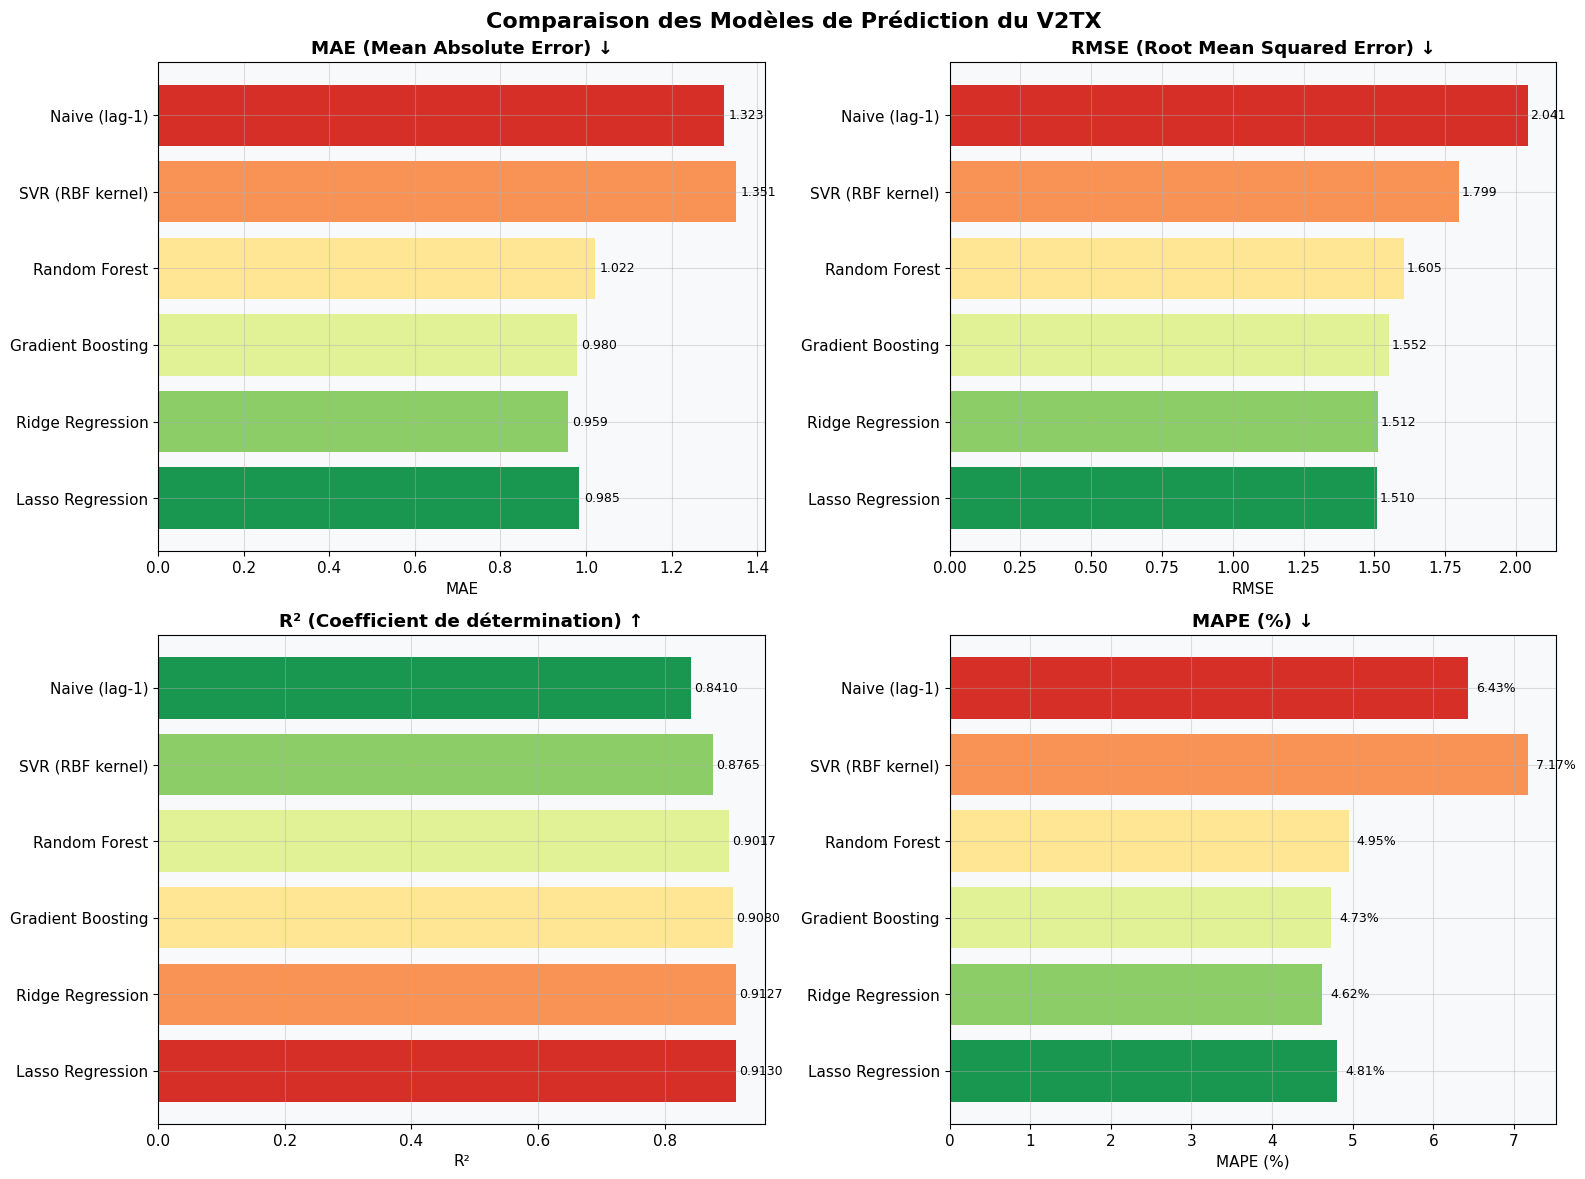

In [17]:
# ─── Visualisation comparaison ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparaison des Modèles de Prédiction du V2TX', fontsize=16, fontweight='bold')

colors_bar = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(df_results)))

# MAE
axes[0,0].barh(df_results['Modèle'], df_results['MAE'], color=colors_bar)
axes[0,0].set_title('MAE (Mean Absolute Error) ↓', fontweight='bold')
axes[0,0].set_xlabel('MAE')
for i, v in enumerate(df_results['MAE']):
    axes[0,0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

# RMSE
axes[0,1].barh(df_results['Modèle'], df_results['RMSE'], color=colors_bar)
axes[0,1].set_title('RMSE (Root Mean Squared Error) ↓', fontweight='bold')
axes[0,1].set_xlabel('RMSE')
for i, v in enumerate(df_results['RMSE']):
    axes[0,1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

# R²
colors_r2 = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(df_results)))
axes[1,0].barh(df_results['Modèle'], df_results['R²'], color=colors_r2)
axes[1,0].set_title('R² (Coefficient de détermination) ↑', fontweight='bold')
axes[1,0].set_xlabel('R²')
axes[1,0].axvline(0, color='black', lw=0.5)
for i, v in enumerate(df_results['R²']):
    axes[1,0].text(max(v, 0) + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

# MAPE
axes[1,1].barh(df_results['Modèle'], df_results['MAPE (%)'], color=colors_bar)
axes[1,1].set_title('MAPE (%) ↓', fontweight='bold')
axes[1,1].set_xlabel('MAPE (%)')
for i, v in enumerate(df_results['MAPE (%)']):
    axes[1,1].text(v + 0.1, i, f'{v:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('03_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

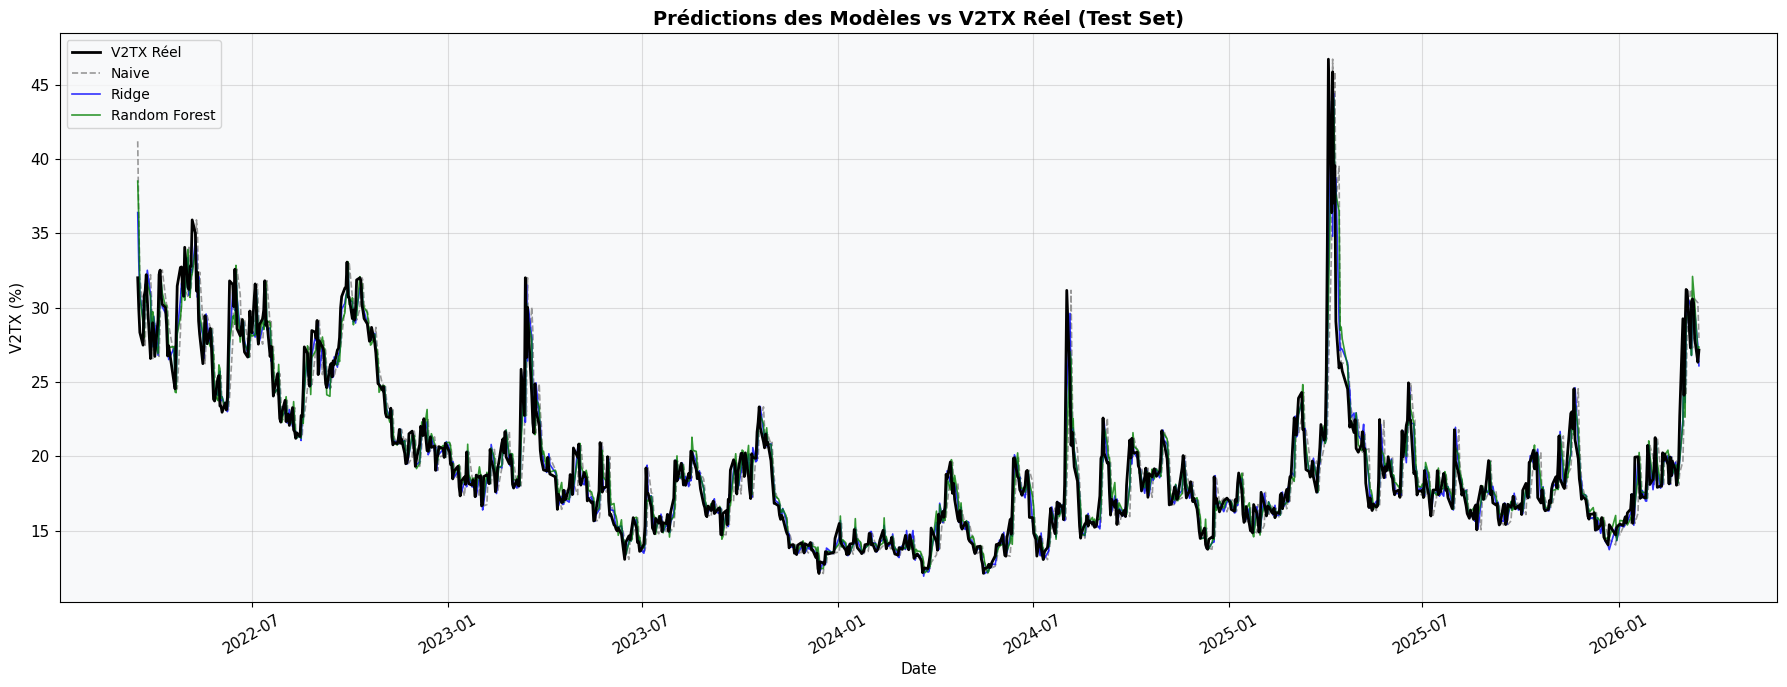

In [18]:
# ─── Visualisation des prédictions vs réel ────────────────────
dates_test = df_test['Date'].values

# Sélectionner les modèles à afficher
models_to_plot = ['Naive', 'Ridge', 'Random Forest', 'XGBoost', 'LSTM']
colors_plot = ['gray', 'blue', 'green', 'orange', 'red']
styles_plot = ['--', '-', '-', '-', '-']

fig, ax = plt.subplots(figsize=(18, 7))
ax.plot(dates_test, predictions['Réel'], color='black', lw=2, label='V2TX Réel', zorder=10)

for model, color, style in zip(models_to_plot, colors_plot, styles_plot):
    if model in predictions and not np.all(np.isnan(predictions[model])):
        ax.plot(dates_test, predictions[model], color=color, lw=1.2,
               linestyle=style, alpha=0.8, label=model)

ax.set_title('Prédictions des Modèles vs V2TX Réel (Test Set)', fontsize=14, fontweight='bold')
ax.set_ylabel('V2TX (%)')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('04_predictions_vs_real.png', dpi=120, bbox_inches='tight')
plt.show()

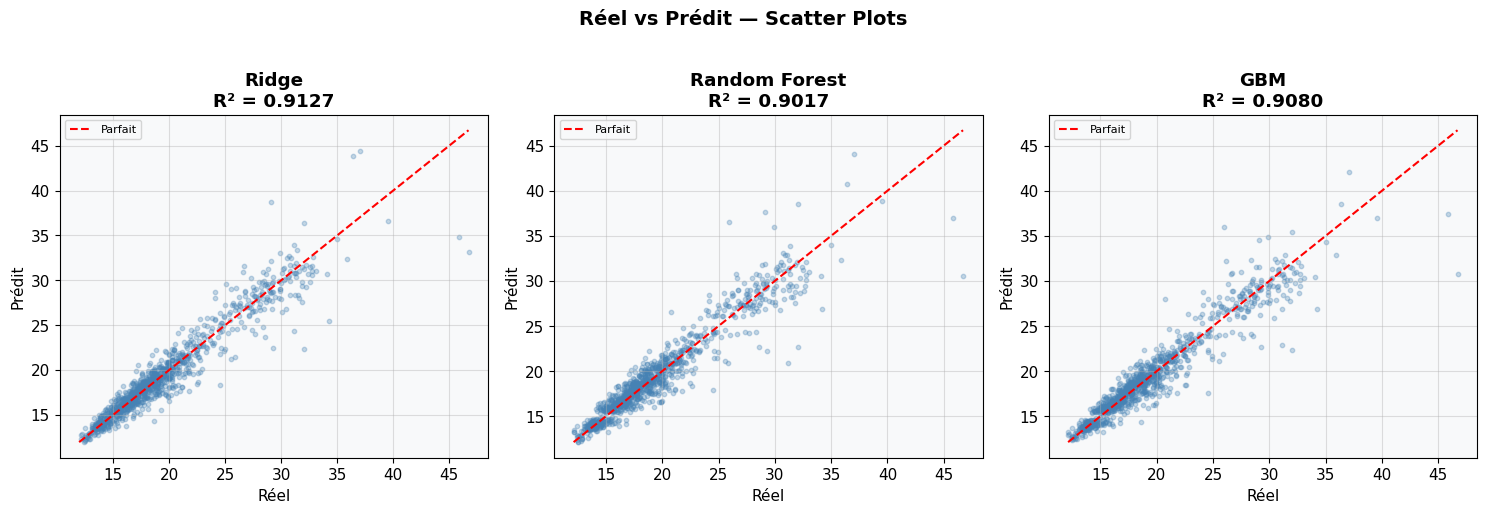

In [19]:
# ─── Scatter plots : prédit vs réel ──────────────────────────
models_eval = ['Ridge', 'Random Forest', 'GBM', 'XGBoost']
models_eval = [m for m in models_eval if m in predictions]

fig, axes = plt.subplots(1, len(models_eval), figsize=(5*len(models_eval), 5))
if len(models_eval) == 1:
    axes = [axes]

for ax, model in zip(axes, models_eval):
    preds = predictions[model]
    mask  = ~np.isnan(preds)
    y_r   = predictions['Réel'][mask]
    y_p   = preds[mask]
    r2    = r2_score(y_r, y_p)

    ax.scatter(y_r, y_p, alpha=0.3, s=10, color='steelblue')
    mn, mx = min(y_r.min(), y_p.min()), max(y_r.max(), y_p.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Parfait')
    ax.set_xlabel('Réel')
    ax.set_ylabel('Prédit')
    ax.set_title(f'{model}\nR² = {r2:.4f}', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Réel vs Prédit — Scatter Plots', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('05_scatter_plots.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Feature Importance

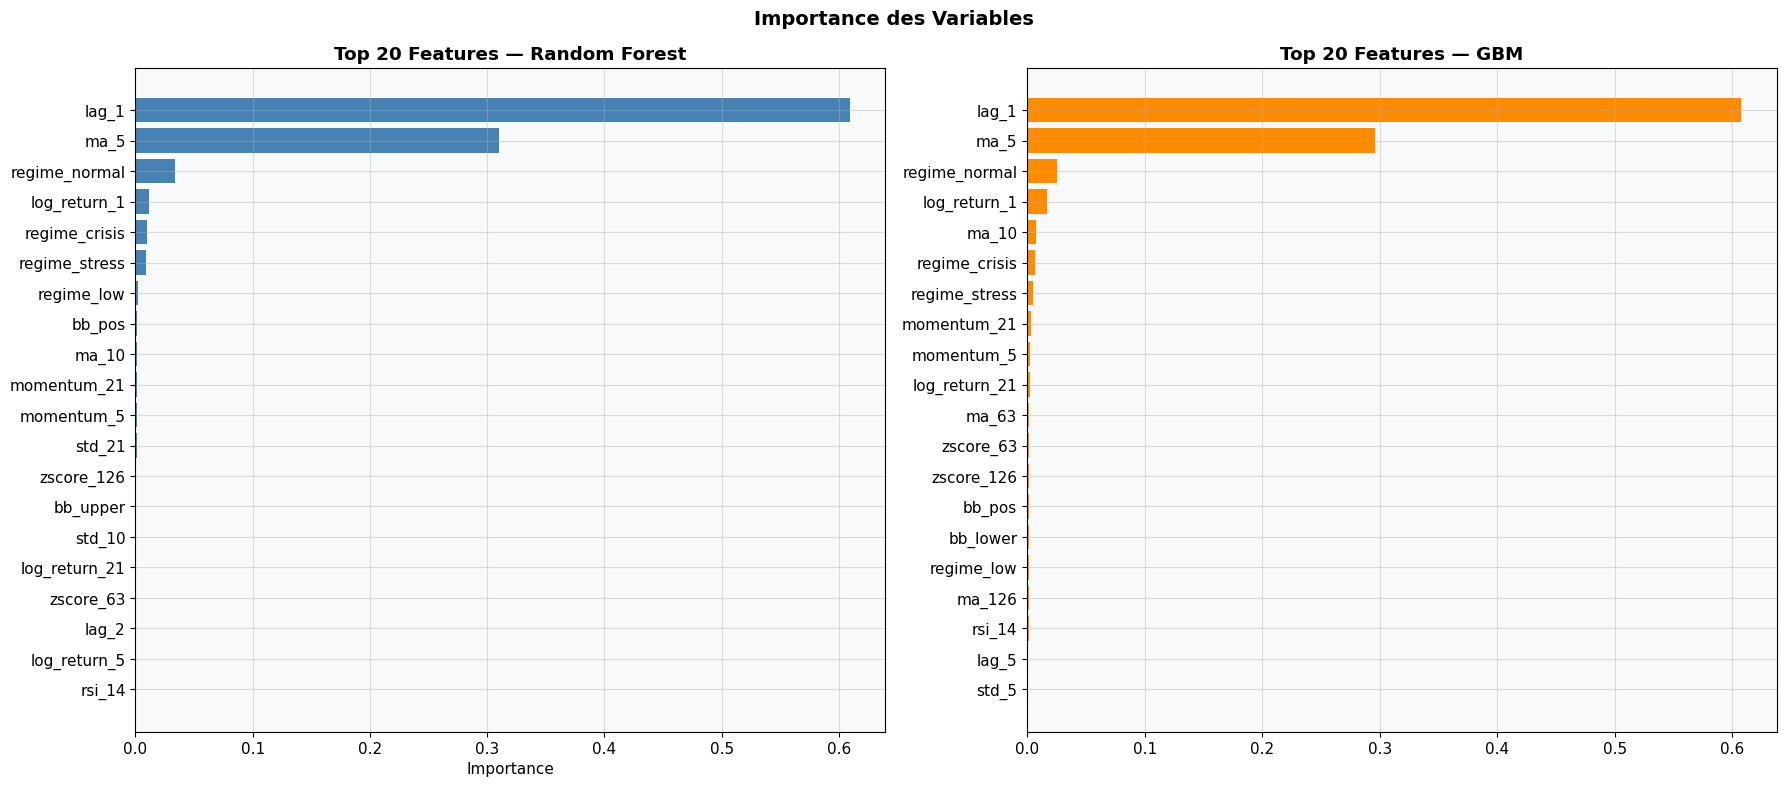


🔑 Top 10 features les plus importantes (Random Forest) :
lag_1            0.608962
ma_5             0.309700
regime_normal    0.033913
log_return_1     0.011400
regime_crisis    0.009663
regime_stress    0.008837
regime_low       0.001950
bb_pos           0.001652
ma_10            0.001587
momentum_21      0.001384


In [20]:
# ─── Feature Importance — Random Forest & XGBoost ─────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Random Forest
fi_rf = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)[:20]
axes[0].barh(fi_rf.index[::-1], fi_rf.values[::-1], color='steelblue')
axes[0].set_title('Top 20 Features — Random Forest', fontweight='bold')
axes[0].set_xlabel('Importance')

# XGBoost
try:
    fi_xgb = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)[:20]
    axes[1].barh(fi_xgb.index[::-1], fi_xgb.values[::-1], color='darkorange')
    axes[1].set_title('Top 20 Features — XGBoost', fontweight='bold')
    axes[1].set_xlabel('Importance')
except:
    fi_gbm = pd.Series(gbm.feature_importances_, index=feature_cols).sort_values(ascending=False)[:20]
    axes[1].barh(fi_gbm.index[::-1], fi_gbm.values[::-1], color='darkorange')
    axes[1].set_title('Top 20 Features — GBM', fontweight='bold')

plt.suptitle('Importance des Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n🔑 Top 10 features les plus importantes (Random Forest) :')
print(fi_rf.head(10).to_string())

## 7. Prédiction Future (30 jours)

In [21]:
# ─── Prédiction récursive 30 jours en avance ──────────────────
FORECAST_DAYS = 30

def forecast_recursive(model, df_full, feature_cols, scaler, n_days, use_scaler=False):
    """
    Prédiction récursive : utilise chaque prédiction comme input du suivant.
    """
    df_sim = build_features(df_full, target_horizon=1)
    preds = []

    for step in range(n_days):
        last_row = df_sim[feature_cols].iloc[[-1]]

        if use_scaler:
            x = scaler.transform(last_row)
        else:
            x = last_row.values

        pred = model.predict(x)[0]
        preds.append(pred)

        # Ajouter la prédiction comme nouvelle observation
        new_date = df_sim['Date'].iloc[-1] + pd.Timedelta(days=1)
        new_row = pd.DataFrame({'Date': [new_date], 'V2TX': [pred]})
        df_sim = pd.concat([df_full, new_row], ignore_index=True)
        df_sim = build_features(df_sim, target_horizon=1)

    return preds

print(f'🔮 Calcul des prédictions {FORECAST_DAYS}j en avance...')

# Générer les dates futures
last_date = df['Date'].max()
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS)

# Prédictions avec RF et GBM
forecasts = {}

try:
    forecasts['Random Forest'] = forecast_recursive(rf, df, feature_cols, scaler, FORECAST_DAYS, use_scaler=False)
    print(f'   ✅ Random Forest : {FORECAST_DAYS} pas prédit')
except Exception as e:
    print(f'   ⚠️  RF : {e}')

try:
    forecasts['GBM'] = forecast_recursive(gbm, df, feature_cols, scaler, FORECAST_DAYS, use_scaler=False)
    print(f'   ✅ GBM : {FORECAST_DAYS} pas prédit')
except Exception as e:
    print(f'   ⚠️  GBM : {e}')

try:
    forecasts['XGBoost'] = forecast_recursive(xgb_model, df, feature_cols, scaler, FORECAST_DAYS, use_scaler=False)
    print(f'   ✅ XGBoost : {FORECAST_DAYS} pas prédit')
except Exception as e:
    print(f'   ⚠️  XGBoost : {e}')

🔮 Calcul des prédictions 30j en avance...
   ✅ Random Forest : 30 pas prédit
   ✅ GBM : 30 pas prédit
   ⚠️  XGBoost : name 'xgb_model' is not defined


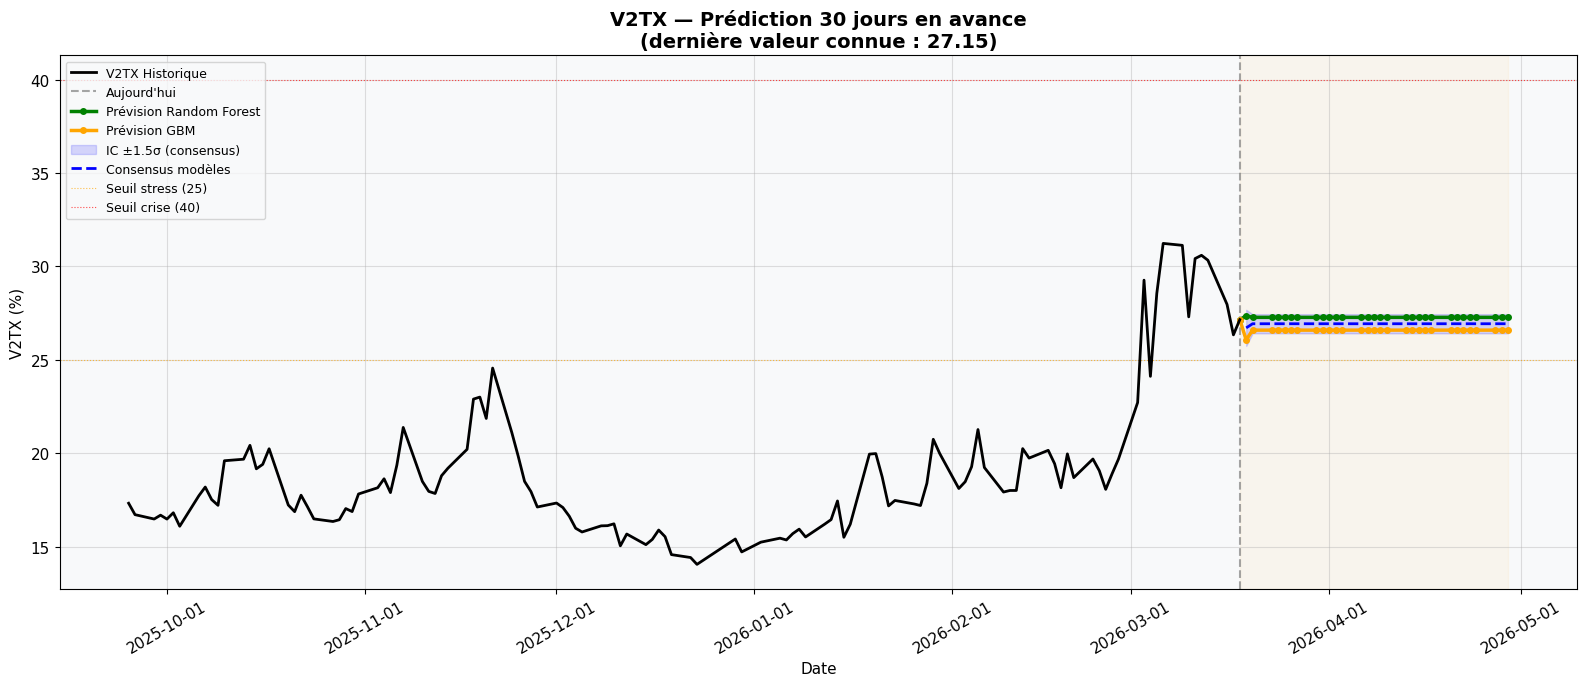


📋 Prédictions V2TX (30 prochains jours) :
            Random Forest    GBM
Date                            
2026-03-19          27.35  26.06
2026-03-20          27.27  26.59
2026-03-23          27.27  26.59
2026-03-24          27.27  26.59
2026-03-25          27.27  26.59
2026-03-26          27.27  26.59
2026-03-27          27.27  26.59
2026-03-30          27.27  26.59
2026-03-31          27.27  26.59
2026-04-01          27.27  26.59
2026-04-02          27.27  26.59
2026-04-03          27.27  26.59
2026-04-06          27.27  26.59
2026-04-07          27.27  26.59
2026-04-08          27.27  26.59
2026-04-09          27.27  26.59
2026-04-10          27.27  26.59
2026-04-13          27.27  26.59
2026-04-14          27.27  26.59
2026-04-15          27.27  26.59
2026-04-16          27.27  26.59
2026-04-17          27.27  26.59
2026-04-20          27.27  26.59
2026-04-21          27.27  26.59
2026-04-22          27.27  26.59
2026-04-23          27.27  26.59
2026-04-24          27.27  26.59


In [22]:
# ─── Visualisation de la prédiction future ────────────────────
LOOKBACK = 120  # Jours historiques à afficher

fig, ax = plt.subplots(figsize=(16, 7))

# Historique récent
hist = df.tail(LOOKBACK)
ax.plot(hist.Date, hist.V2TX, color='black', lw=2, label='V2TX Historique', zorder=10)

# Zone de séparation
ax.axvline(last_date, color='gray', linestyle='--', lw=1.5, alpha=0.7, label='Aujourd\'hui')
ax.axvspan(last_date, future_dates[-1], alpha=0.05, color='orange')

# Prédictions
fc_colors = {'Random Forest': 'green', 'GBM': 'orange', 'XGBoost': 'red', 'LSTM': 'purple'}
for model, preds in forecasts.items():
    fc_dates = [last_date] + list(future_dates[:len(preds)])
    fc_vals  = [df.V2TX.iloc[-1]] + list(preds)
    color = fc_colors.get(model, 'blue')
    ax.plot(fc_dates, fc_vals, color=color, lw=2.5, linestyle='-',
           marker='o', markersize=4, label=f'Prévision {model}', zorder=9)

# Intervalles de confiance (±1 std des prédictions)
if len(forecasts) >= 2:
    all_fc = np.array(list(forecasts.values()))
    mean_fc = all_fc.mean(axis=0)
    std_fc  = all_fc.std(axis=0)
    fc_x = list(future_dates[:len(mean_fc)])
    ax.fill_between(fc_x, mean_fc - 1.5*std_fc, mean_fc + 1.5*std_fc,
                    alpha=0.15, color='blue', label='IC ±1.5σ (consensus)')
    ax.plot(fc_x, mean_fc, color='blue', lw=2, linestyle='--', label='Consensus modèles')

# Niveaux de référence
ax.axhline(25, color='orange', lw=0.8, linestyle=':', alpha=0.7, label='Seuil stress (25)')
ax.axhline(40, color='red',    lw=0.8, linestyle=':', alpha=0.7, label='Seuil crise (40)')

ax.set_title(f'V2TX — Prédiction {FORECAST_DAYS} jours en avance\n(dernière valeur connue : {df.V2TX.iloc[-1]:.2f})',
            fontsize=14, fontweight='bold')
ax.set_ylabel('V2TX (%)')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('07_forecast_30days.png', dpi=120, bbox_inches='tight')
plt.show()

# Tableau des prédictions futures
if forecasts:
    df_forecast = pd.DataFrame(forecasts, index=future_dates[:max(len(v) for v in forecasts.values())])
    df_forecast.index.name = 'Date'
    print('\n📋 Prédictions V2TX (30 prochains jours) :')
    print(df_forecast.round(2).to_string())

## 8. Analyse des Erreurs & Résumé Final

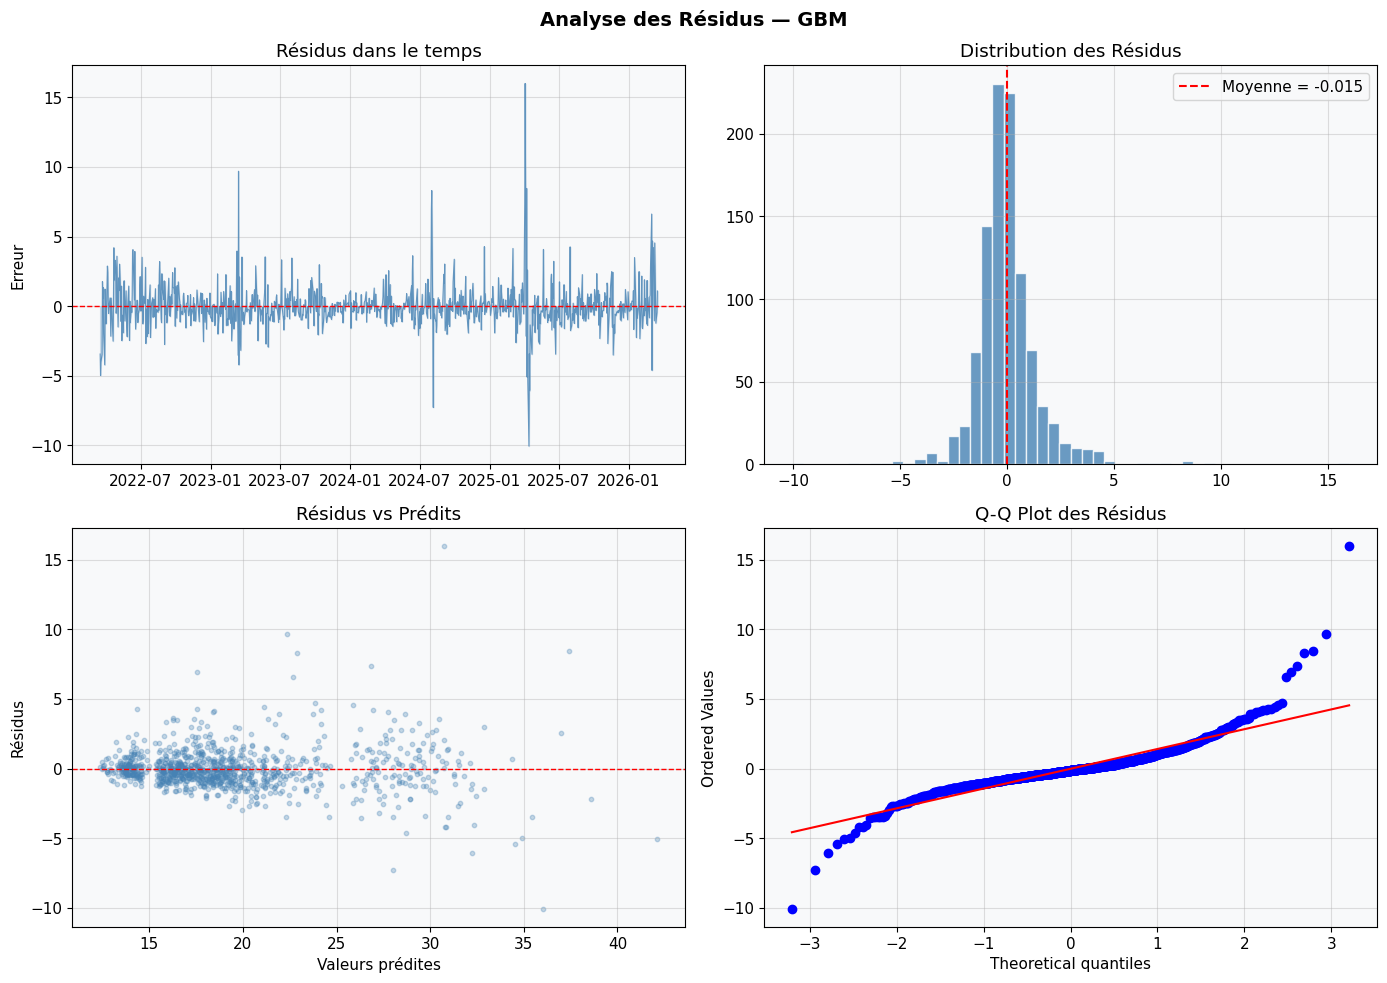

In [23]:
# ─── Analyse des résidus ──────────────────────────────────────
best_model_name = df_results.iloc[0]['Modèle']
# Trouver le meilleur modèle disponible
best_available = None
for model in ['XGBoost', 'GBM', 'Random Forest', 'Ridge']:
    if model in predictions:
        best_available = model
        break

if best_available:
    residuals = predictions['Réel'] - predictions[best_available]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Analyse des Résidus — {best_available}', fontsize=14, fontweight='bold')

    # Résidus temporels
    axes[0,0].plot(dates_test, residuals, color='steelblue', lw=0.8, alpha=0.8)
    axes[0,0].axhline(0, color='red', linestyle='--', lw=1)
    axes[0,0].fill_between(dates_test, residuals, alpha=0.2, color='steelblue')
    axes[0,0].set_title('Résidus dans le temps')
    axes[0,0].set_ylabel('Erreur')

    # Distribution des résidus
    axes[0,1].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0,1].axvline(np.mean(residuals), color='red', linestyle='--', label=f'Moyenne = {np.mean(residuals):.3f}')
    axes[0,1].set_title('Distribution des Résidus')
    axes[0,1].legend()

    # Résidus vs Valeurs prédites
    axes[1,0].scatter(predictions[best_available], residuals, alpha=0.3, s=10, color='steelblue')
    axes[1,0].axhline(0, color='red', linestyle='--', lw=1)
    axes[1,0].set_xlabel('Valeurs prédites')
    axes[1,0].set_ylabel('Résidus')
    axes[1,0].set_title('Résidus vs Prédits')

    # Q-Q plot
    from scipy import stats
    stats.probplot(residuals[~np.isnan(residuals)], dist='norm', plot=axes[1,1])
    axes[1,1].set_title('Q-Q Plot des Résidus')

    plt.tight_layout()
    plt.savefig('08_residuals.png', dpi=120, bbox_inches='tight')
    plt.show()

In [24]:
# ─── Résumé final ─────────────────────────────────────────────
print('\n' + '='*70)
print('  RÉSUMÉ FINAL — PRÉDICTION DE VOLATILITÉ V2TX (VSTOXX)')
print('='*70)

print(f"""
📊 DONNÉES
   Série      : V2TX (VSTOXX) — Volatilité implicite Euro Stoxx 50
   Période    : {df.Date.min().date()} → {df.Date.max().date()}
   Observations: {len(df):,} points journaliers
   Horizon prédit: J+{HORIZON}

🔧 FEATURES CONSTRUITES ({len(feature_cols)} variables)
   - Lags temporels (1j, 2j, 3j, 5j, 10j, 21j, 63j)
   - Moyennes mobiles (5j, 10j, 21j, 63j, 126j)
   - Volatilité réalisée (rolling std)
   - RSI, Bandes de Bollinger, Z-score
   - Momentum, Log-rendements
   - Régimes de volatilité (low/normal/stress/crisis)
   - Variables calendaires

🤖 MODÈLES COMPARÉS
   1. Naive (baseline)
   2. Ridge Regression
   3. Lasso Regression  
   4. Random Forest
   5. Gradient Boosting
   6. XGBoost
   7. SVR (RBF)
   8. LSTM (Deep Learning)
   9. GARCH(1,1) (référence financière)
""")

print('📈 RÉSULTATS (triés par RMSE) :')
print(df_results.to_string(index=False))

print(f"""
🏆 GAGNANT : {df_results.iloc[0]['Modèle']}

⚠️  NOTES IMPORTANTES
   - Les modèles ML prédisent bien les tendances mais peinent
     sur les chocs extrêmes (11-Sep, Lehman, Covid)
   - R² élevé ≠ bon modèle financier (attention à l'overfitting)
   - La prédiction récursive accumule les erreurs sur l'horizon
   - Pour usage réel : valider avec walk-forward cross-validation
     et intégrer des variables macro (VIX, spreads crédit, etc.)
""")

print('📁 Graphiques générés :')
for i, g in enumerate(['01_exploration', '02_correlations', '03_model_comparison',
                        '04_predictions_vs_real', '05_scatter_plots',
                        '06_feature_importance', '07_forecast_30days', '08_residuals'], 1):
    print(f'   {i}. {g}.png')

print('\n✅ Notebook terminé.')


  RÉSUMÉ FINAL — PRÉDICTION DE VOLATILITÉ V2TX (VSTOXX)

📊 DONNÉES
   Série      : V2TX (VSTOXX) — Volatilité implicite Euro Stoxx 50
   Période    : 1999-01-04 → 2026-03-18
   Observations: 6,926 points journaliers
   Horizon prédit: J+1

🔧 FEATURES CONSTRUITES (39 variables)
   - Lags temporels (1j, 2j, 3j, 5j, 10j, 21j, 63j)
   - Moyennes mobiles (5j, 10j, 21j, 63j, 126j)
   - Volatilité réalisée (rolling std)
   - RSI, Bandes de Bollinger, Z-score
   - Momentum, Log-rendements
   - Régimes de volatilité (low/normal/stress/crisis)
   - Variables calendaires

🤖 MODÈLES COMPARÉS
   1. Naive (baseline)
   2. Ridge Regression
   3. Lasso Regression  
   4. Random Forest
   5. Gradient Boosting
   6. XGBoost
   7. SVR (RBF)
   8. LSTM (Deep Learning)
   9. GARCH(1,1) (référence financière)

📈 RÉSULTATS (triés par RMSE) :
           Modèle    MAE   RMSE     R²  MAPE (%)
 Lasso Regression 0.9848 1.5102 0.9130      4.81
 Ridge Regression 0.9587 1.5124 0.9127      4.62
Gradient Boosting 0.9